#### Interpolating native ECCO V4r4 onto a $0.5^\circ$ grid using MeshArrays.jl and ECCOtour.jl

#### Load in packages and relevant LLC90 grid information

In [1]:
using Revise
using ECCOtour, MeshArrays, 
      MITgcmTools, JLD2, 
      LaTeXStrings
using PythonCall
import PythonPlot as plt

plt.matplotlib.rcParams["figure.dpi"] = 50
# plt.pygui(false)

matplotlib = pyimport("matplotlib")
sns = pyimport("seaborn")
cartopy = pyimport("cartopy")
ccrs = cartopy.crs
include("../src/config_exp.jl");

In [3]:
runpath,diagpath = listexperiments(exprootdir());
tecco = range(1992,step=1/12,stop=2018)
ocean_mask = wet_pts(Γ)
area = readarea(γ);
Depth = Γ.Depth;

interannual_eqpac
iter129_bulkformula
noinitadjust
nosfcadjust
nointerannual_buoyancy
nointerannual_wind
interannual_southpac
climatological_tau
seasonalclimatology_iter0
add_sigma1_windstresscurl.m
iter0_bulkformula
nointerannual_eqpac
interannual_southpac_cora
checkout_plots.m
iter129_fluxforced
interannual_northpac
nointerannual
compare_timeseries.m


#### Plot the depth of each column in ECCO V4r4 (as best we can)

In [19]:
(ϕ,λ) = latlonC(γ);
for ff ∈ 3:5 
    λ[ff][λ[ff] .<= 0 ] = mod.(λ[ff][λ[ff] .<= 0 ] .+ 360, 360)
end

# Define the figure and each axis for the 3 rows and 3 columns
fig, axs = plt.subplots(nrows=1,ncols=1,
                        figsize=(11,8.5));
for ff = 1:5
    axs.pcolormesh(λ[ff], ϕ[ff], Depth[ff], vmin = 0, vmax = 6000, cmap = "bwr",shading="nearest")
end;
display(fig)

#### Interpolate onto a regular grid

In [4]:
λ=interpolation_setup() #download pre-computed half-degree interpolation factors
λ=jldopen(λ)
lon = λ["lon"]
lat = λ["lat"]
f = λ["f"]
i = λ["i"]
j = λ["j"]
w = λ["w"];

DD = Interpolate(Depth,f,i,j,w) #interpolate using half-degree resolution
DD = reshape(DD, size(lon));

#### Plot interpolated depths, *looks pretty good*! 

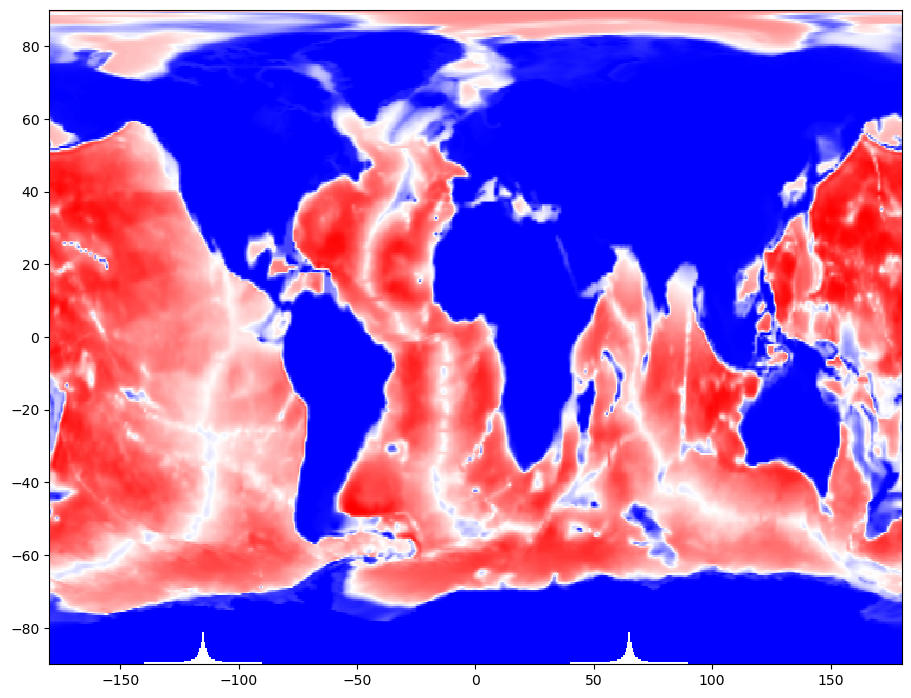

In [5]:
# Define the figure and each axis for the 3 rows and 3 columns
fig, axs = plt.subplots(nrows=1,ncols=1,
                        figsize=(11,8.5))
axs.pcolormesh(lon, lat, DD, vmin = 0, vmax = 6000, cmap = "bwr",shading="nearest", rasterized = true)
display(fig)